In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from cycler import cycler

plt.style.use("seaborn-v0_8")
plt.rcParams.clear()
plt.rcParams.update({
    "font.family": "serif",
    "axes.facecolor": "#FFFFFF",
    "axes.grid": True,
    "axes.grid.which": "major",
    "axes.grid.axis": "both",
    "axes.spines.bottom": True,
    "axes.spines.left": True,
    "axes.spines.right": True,
    "axes.spines.top": True,
    "axes.labelsize": 14,
    "grid.color": "#BBBBBB",
    "grid.linestyle": "--",
    "grid.linewidth": .5,
    "figure.frameon": True,
    "legend.fontsize": 11
})

c = cycler(color=[
    
    (230/255, 159/255, 0/255), # orange
    
    (0/255, 158/255, 115/255), # blueish green
    (86/255, 180/255, 233/255), # sky blue
    # (0/255, 114/255, 178/255), # blue
    # (213/255, 94/255, 0/255), # vermillion
    (204/255, 121/255, 167/255), # reddish purple
    (240/255, 228/255, 66/255), # yellow
])

plt.rc('axes', prop_cycle=c)

In [3]:
SCENARIOS = ["without_combinations", "join_first", "union_first"]
N_ENTRIES = ["1M", "10M", "50M", "100M"]

n_entries2numeric = {
    "1M": 1_000_000,
    "10M": 10_000_000,
    "50M": 50_000_000,
    "100M": 100_000_000
}

df = pd.DataFrame()
for s in SCENARIOS:
    for i, n_entries in enumerate(N_ENTRIES):
        walltime = np.loadtxt(f"./results/scenario1_{s}/{n_entries}.csv", delimiter=",", skiprows=1, usecols=2)
        row = {"scenario": [s], "n_entries": [n_entries2numeric[n_entries]], "walltime_mean": [walltime.mean() * 1e-6], "walltime_std": [walltime.std() * 1e-6]}
        df = pd.concat([df, pd.DataFrame(row)])
        
    
df = df.pivot(index="n_entries", columns="scenario")
df

walltime_mean                                  walltime_std  \
scenario     join_first union_first without_combinations   join_first   
n_entries                                                               
1000000        0.418956    0.421127             0.484441     0.004890   
10000000       1.400970    1.457361             2.378709     0.046267   
50000000       5.259419    5.567635            10.247286     0.058659   
100000000     10.477865   10.617898            19.949585     0.414356   

                                            
scenario  union_first without_combinations  
n_entries                                   
1000000      0.006546             0.004142  
10000000     0.013941             0.049025  
50000000     0.148757             0.134493  
100000000    0.078941             0.237742

In [4]:
df_mean_diff = df.walltime_mean

for col in SCENARIOS:
    df_mean_diff[col] = 1 - (df_mean_diff[col] / df.walltime_mean["without_combinations"])
    
df_mean_diff

/tmp/ipykernel_38305/1202593542.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mean_diff[col] = 1 - (df_mean_diff[col] / df.walltime_mean["without_combinations"])


scenario,join_first,union_first,without_combinations
n_entries,,,
1000000,0.135175,0.130695,0.0
10000000,0.411038,0.387331,0.0
50000000,0.486750,0.456672,0.0
100000000,0.474783,0.467763,0.0


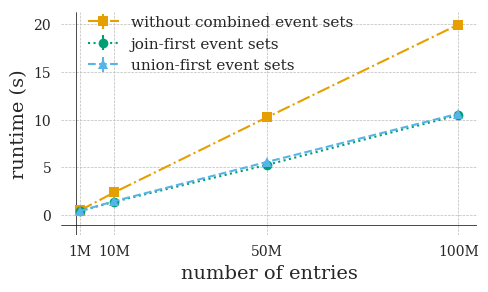

In [17]:
fig, ax = plt.subplots(figsize=(5,3))
ax.set_xticks(df.index, labels=n_entries2numeric.keys())
ax.set_xlabel("number of entries")
ax.set_ylabel("runtime (s)")

ax.errorbar(df.index,
            df.walltime_mean["without_combinations"],
            yerr=df.walltime_std["without_combinations"],
            linestyle="dashdot",
            linewidth=1.5,
            marker="s",
            # color="#F2A922"
           )

ax.errorbar(df.index,
            df.walltime_mean["join_first"],
            yerr=df.walltime_std["join_first"],
            linestyle="dotted",
            linewidth=1.5,
            marker="o",
            # color="#0000FF"
           )

ax.errorbar(df.index,
            df.walltime_mean["union_first"],
            yerr=df.walltime_std["union_first"],
            linestyle="dashed",
            linewidth=1.5,
            marker="^",
            # color="#0BB343"
           )

# ax.set_ylim([0, 22])
ax.legend(["without combined event sets", "join-first event sets", "union-first event sets"], loc=(.05, .7))

ax.axhline(-1, color='black', linewidth=.5)
ax.axvline(0, color='black', linewidth=.5)

fig.tight_layout()
fig.savefig("plots/runtime_scenario1.pdf", transparent=True)
fig.savefig("/home/florine/cernbox/2025_EP_RND_DAY/runtime_scenario1.png", transparent=True, dpi=1000)
fig.savefig("plots/runtime_scenario1.tex", format="pgf", transparent=True)
fig.savefig("/home/florine/cern/papers/escience25/figures/runtime_scenario1.tex", format="pgf", transparent=True)